## Imports and configuration

In [1]:
# pip install numpy pandas matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import zip_longest

In [2]:
DATA_DIR = Path("../outputs/")

SCENARIOS = {
    2000: ("veh_norec_2000.csv", "veh_rec_2000.csv"),
    2400: ("veh_norec_2400.csv", "veh_rec_2400.csv"),
    2800: ("veh_norec_2800.csv", "veh_rec_2800.csv"),
}

## Load data

In [8]:
def load(path: Path) -> pd.DataFrame:
    df = pd.read_csv(
        path,
        encoding="utf-8",
        on_bad_lines="skip",   # drops the truncated last line
    )
    df["sim_time_s"] = df["sim_time_ns"] / 1e9
    return df

dfs = {}
for n_cars, (no_rec, with_rec) in SCENARIOS.items():
    dfs[(n_cars, "without")] = load(DATA_DIR / no_rec)
    dfs[(n_cars, "with")]    = load(DATA_DIR / with_rec)

print("Loaded scenarios:", list(SCENARIOS.keys()))

Loaded scenarios: [2000, 2400, 2800]


## Build table connecting Transmission to Reception

In [12]:
def build_pairs(df: pd.DataFrame) -> pd.DataFrame:
    tx = df[df["direction"] == "TX"][[
        "msg_id", "sender_name", "sim_time_s", "hop_count",
        "sender_lat", "sender_lon", "speed_mps"
    ]].copy()

    rx = df[df["direction"] == "RX"][[
        "msg_id", "observer_node", "receiver_time_ns"
    ]].copy()
    rx["receiver_time_s"] = rx["receiver_time_ns"] / 1e9

    # One TX row can be received by many vehicles → left join expands correctly
    pairs = tx.merge(rx, on="msg_id", how="left")
    pairs["received"]   = pairs["observer_node"].notna()
    pairs["latency_ms"] = (pairs["receiver_time_s"] - pairs["sim_time_s"]) * 1000

    del tx, rx
    return pairs

pairs = {}
for key, df in dfs.items():
    pairs[key] = build_pairs(df)

print("Pairs built.")

Pairs built.


In [13]:
print(pairs)

{(2000, 'without'):          msg_id sender_name  sim_time_s  hop_count  sender_lat  sender_lon  \
0             0       veh_0         2.2          0   36.897180  -23.730468   
1             1       veh_1         2.2          0   36.897495  -23.719259   
2             2       veh_0         2.4          0   36.897180  -23.730468   
3             3       veh_1         2.4          0   36.897495  -23.719259   
4             4       veh_0         2.6          0   36.897180  -23.730468   
...         ...         ...         ...        ...         ...         ...   
2579520  202533     veh_749      1000.0          0   36.897340  -23.722248   
2579521  202534     veh_746      1000.0          0   36.897355  -23.721566   
2579522  202535     veh_743      1000.0          0   36.897372  -23.720810   
2579523  202536     veh_727      1000.0          0   36.897403  -23.719489   
2579524  202537     veh_737      1000.0          0   36.897386  -23.720205   

         speed_mps observer_node  receiver_

## Summary statistics table

In [15]:
def summarize_veh(n_cars: int, label: str) -> dict:
    df   = dfs[(n_cars, label)]
    pair = pairs[(n_cars, label)]

    tx_df = df[df["direction"] == "TX"]
    rx_df = df[df["direction"] == "RX"]

    delivered      = pair[pair["received"]]
    delivery_ratio = len(delivered) / len(pair) if len(pair) > 0 else 0

    return {
        "Label":              f"{n_cars} — {label}",
        "Total TX":           len(tx_df),
        "Total RX":           len(rx_df),
        "Delivery ratio (%)": round(delivery_ratio * 100, 2),
        "Avg latency (ms)":   round(delivered["latency_ms"].mean(), 3),
        "P95 latency (ms)":   round(delivered["latency_ms"].quantile(0.95), 3),
        "Avg hop count":      round(tx_df["hop_count"].mean(), 2),
        "Max hop count":      tx_df["hop_count"].max(),
        "Unique senders":     tx_df["sender_name"].nunique(),
        "Avg speed (m/s)":    round(tx_df["speed_mps"].mean(), 2),
    }

rows = []
for n_cars in SCENARIOS:
    rows.append(summarize_veh(n_cars, "without"))
    rows.append(summarize_veh(n_cars, "with"))

summary_df = pd.DataFrame(rows).set_index("Label")
summary_df

,Total TX,Total RX,Delivery ratio (%),Avg latency (ms),P95 latency (ms),Avg hop count,Max hop count,Unique senders,Avg speed (m/s)
Label,,,,,,,,,
2000 — without,199587,2579152,99.99,0.0,0.0,0.12,1.0,778,21.08
2000 — with,194307,3103517,99.99,0.0,0.0,0.14,1.0,636,16.70
2400 — without,141952,1066847,99.98,0.0,0.0,0.08,1.0,884,33.20
2400 — with,146695,1142034,99.98,0.0,0.0,0.08,1.0,884,32.10
2800 — without,227584,4711122,100.00,0.0,0.0,0.16,1.0,675,14.99
2800 — with,326967,7073607,99.99,0.0,0.0,0.16,1.0,797,12.58


## Delta table (explicit difference)

In [17]:
delta_rows = []
for n_cars in SCENARIOS:
    wo = summarize_veh(n_cars, "without")
    wi = summarize_veh(n_cars, "with")
    numeric_cols = [k for k in wo if k != "Label"]
    delta = {"Scenario": f"{n_cars} cars"}
    for col in numeric_cols:
        if isinstance(wo[col], (int, float)):
            delta[f"Δ {col}"] = round(wi[col] - wo[col], 3)
    delta_rows.append(delta)

delta_df = pd.DataFrame(delta_rows).set_index("Scenario")

improve_cols = [c for c in delta_df.columns if any(x in c.lower() for x in ["delivery", "unique"])]
worsen_cols  = [c for c in delta_df.columns if any(x in c.lower() for x in ["latency", "hop"])]

def color(v, higher_is_better=True):
    if not isinstance(v, (int, float)): return ""
    good = v > 0 if higher_is_better else v < 0
    return "color: green" if good else "color: red"

delta_df.style\
    .map(lambda v: color(v, True),  subset=improve_cols)\
    .map(lambda v: color(v, False), subset=worsen_cols)

,Δ Total TX,Δ Total RX,Δ Delivery ratio (%),Δ Avg latency (ms),Δ P95 latency (ms),Δ Avg hop count,Δ Unique senders,Δ Avg speed (m/s),Δ Max hop count
Scenario,,,,,,,,,
2000 cars,-5280,524365,0.000000,0.000000,0.000000,0.020000,-142,-4.380000,nan
2400 cars,4743,75187,0.000000,0.000000,0.000000,0.000000,0,-1.100000,nan
2800 cars,99383,2362485,-0.010000,0.000000,0.000000,0.000000,122,-2.410000,0.000000


## Transmission/Reception message volume over time

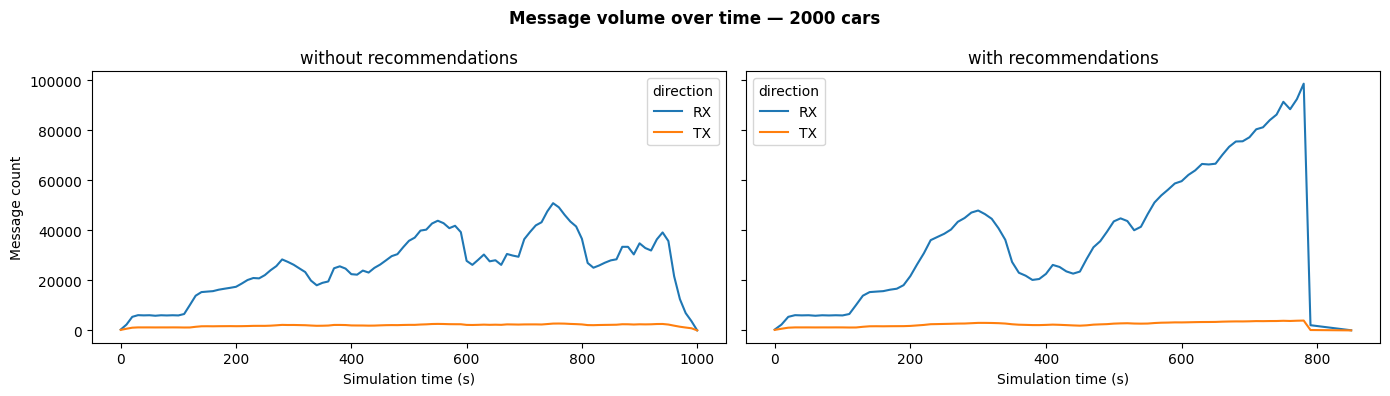

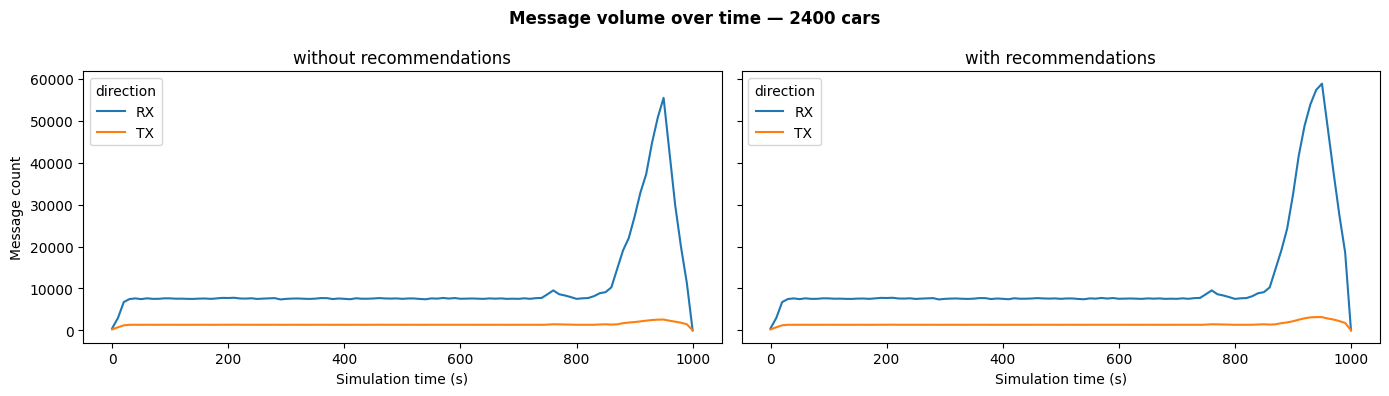

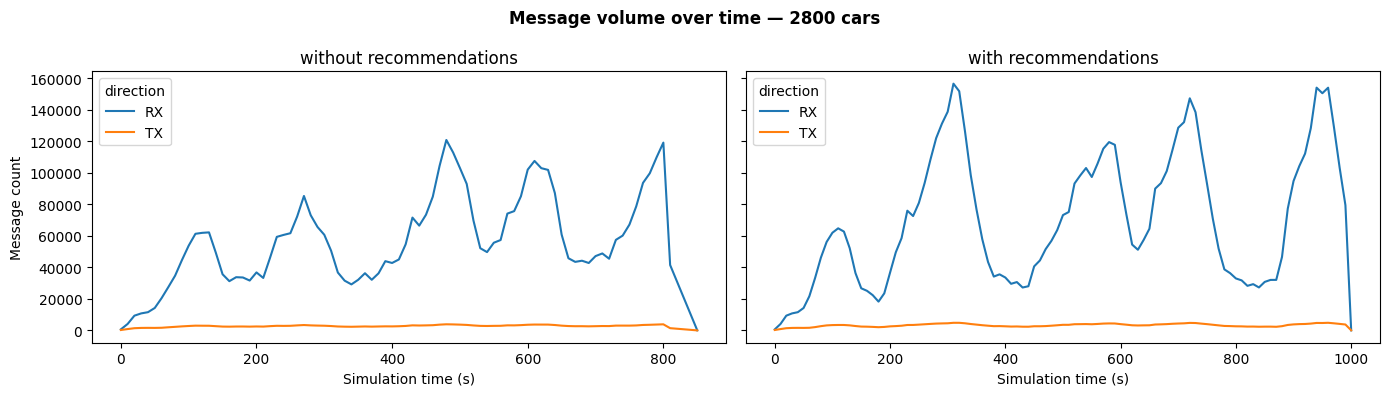

In [18]:
BIN_SIZE_S = 10  # time bin width in seconds

for n_cars in SCENARIOS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    fig.suptitle(f"Message volume over time — {n_cars} cars", fontweight="bold")

    for ax, label in zip(axes, ["without", "with"]):
        df = dfs[(n_cars, label)]
        df["time_bin"] = (df["sim_time_s"] // BIN_SIZE_S) * BIN_SIZE_S
        counts = df.groupby(["time_bin", "direction"]).size().unstack(fill_value=0)
        counts.plot(ax=ax, title=f"{label} recommendations")
        ax.set_xlabel("Simulation time (s)")
        ax.set_ylabel("Message count")

    plt.tight_layout()
    plt.show()

## Delivery ratio

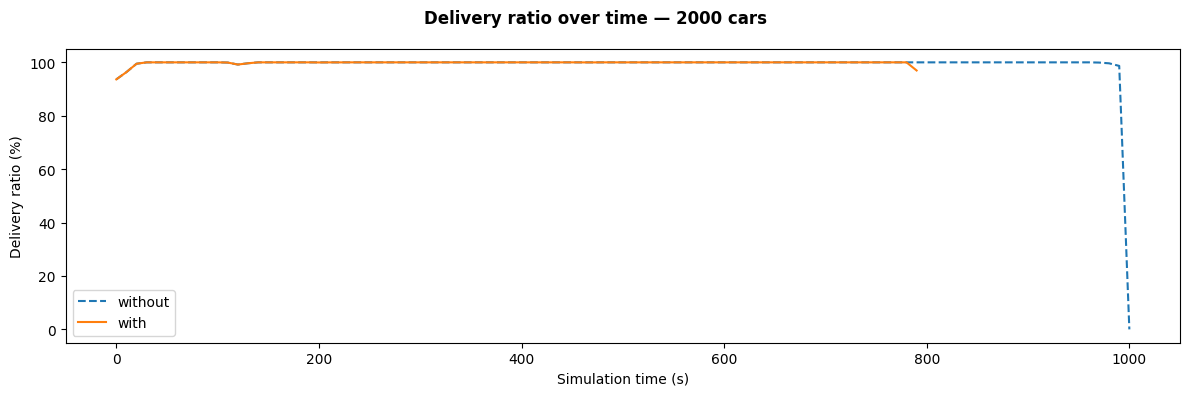

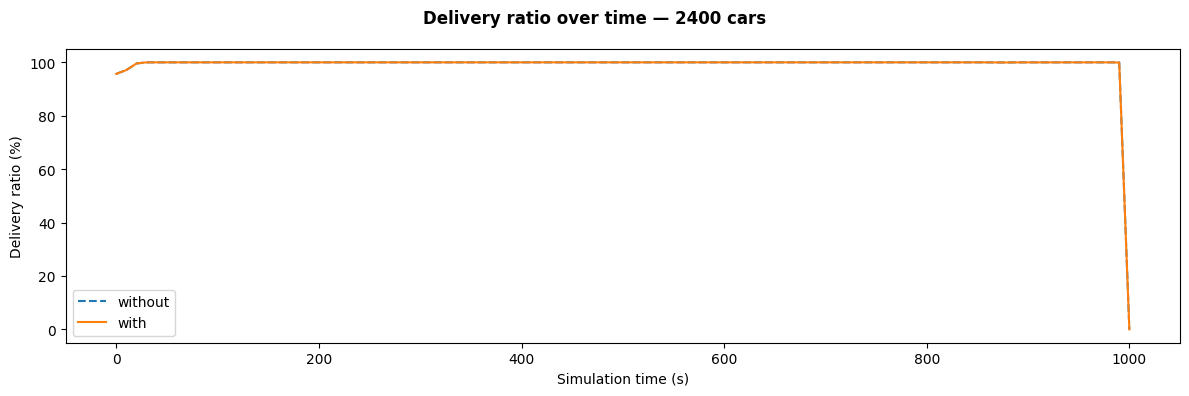

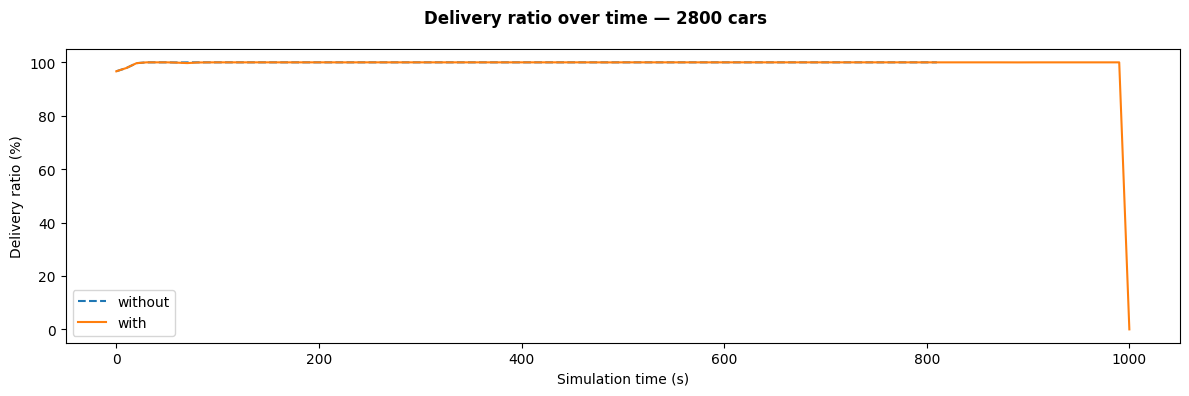

In [19]:
for n_cars in SCENARIOS:
    fig, ax = plt.subplots(figsize=(12, 4))
    fig.suptitle(f"Delivery ratio over time — {n_cars} cars", fontweight="bold")

    for label, style in [("without", "--"), ("with", "-")]:
        p = pairs[(n_cars, label)].copy()
        p["time_bin"] = (p["sim_time_s"] // BIN_SIZE_S) * BIN_SIZE_S
        ratio = p.groupby("time_bin")["received"].mean() * 100
        ax.plot(ratio.index, ratio.values, linestyle=style, label=label)

    ax.set_xlabel("Simulation time (s)")
    ax.set_ylabel("Delivery ratio (%)")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Cross-scenario comparison bar chart

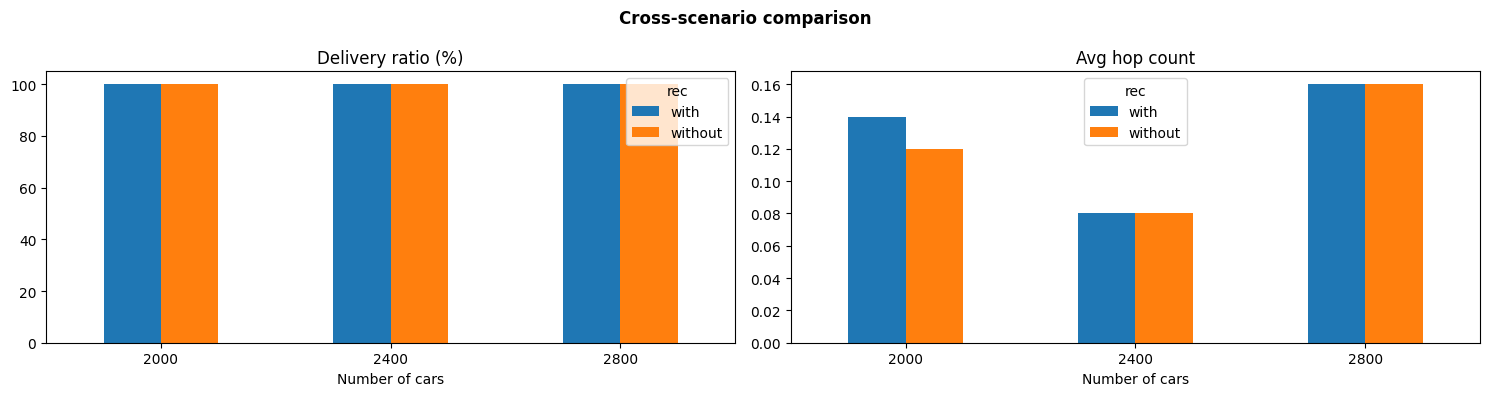

In [23]:
metrics = ["Delivery ratio (%)", "Avg hop count"]
fig, axes = plt.subplots(1, len(metrics), figsize=(15, 4))
fig.suptitle("Cross-scenario comparison", fontweight="bold")

for ax, metric in zip(axes, metrics):
    data = summary_df[metric].reset_index()
    data["n_cars"] = data["Label"].str.extract(r"(\d+)").astype(int)
    data["rec"]    = data["Label"].apply(lambda x: "with" if x.endswith("with") else "without")
    pivot = data.pivot(index="n_cars", columns="rec", values=metric)
    pivot.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(metric)
    ax.set_xlabel("Number of cars")

plt.tight_layout()
plt.show()